In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Independent variable (X) -> Hours studied
X = np.array([1, 2, 3, 4, 5, 6, 7, 8])

# Dependent variable (y) -> Exam scores
y = np.array([52, 55, 59, 63, 68, 72, 75, 79])

# Number of training examples
m = len(X)

print("Total samples:", m)
print("X:", X)
print("y:", y)

Total samples: 8
X: [1 2 3 4 5 6 7 8]
y: [52 55 59 63 68 72 75 79]


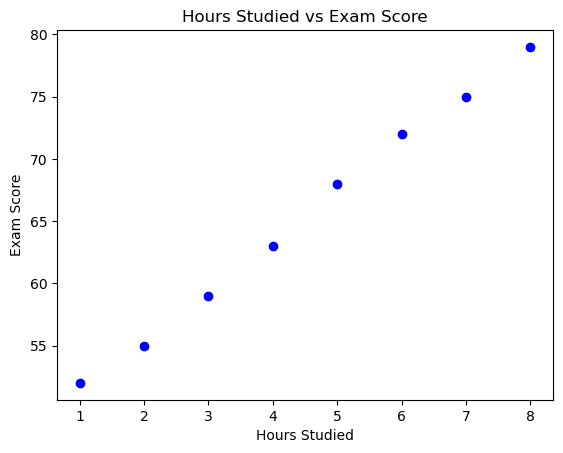

In [3]:
# Scatter plot of data
plt.scatter(X, y, color='blue')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

In [4]:
# Initialize slope (m) and intercept (b)
weight = 0   # slope
bias = 0     # intercept

# Learning rate
learning_rate = 0.01

# Number of iterations
iterations = 1000

In [5]:
def compute_cost(X, y, weight, bias):
    total_cost = 0
    n = len(X)
    
    for i in range(n):
        prediction = weight * X[i] + bias
        total_cost += (prediction - y[i]) ** 2
        
    cost = total_cost / (2 * n)
    return cost

In [6]:
def gradient_descent(X, y, weight, bias, learning_rate, iterations):
    n = len(X)
    cost_history = []
    
    for iteration in range(iterations):
        dw = 0
        db = 0
        
        # Calculate gradients
        for i in range(n):
            prediction = weight * X[i] + bias
            
            dw += (prediction - y[i]) * X[i]
            db += (prediction - y[i])
        
        # Average gradients
        dw = dw / n
        db = db / n
        
        # Update parameters
        weight = weight - learning_rate * dw
        bias = bias - learning_rate * db
        
        # Store cost
        cost = compute_cost(X, y, weight, bias)
        cost_history.append(cost)
        
        # Print every 100 iterations
        if iteration % 100 == 0:
            print(f"Iteration {iteration}: Cost = {cost:.4f}")
    
    return weight, bias, cost_history

In [7]:
# Train model
weight, bias, cost_history = gradient_descent(
    X, y, weight, bias, learning_rate, iterations
)

print("\nFinal Parameters:")
print("Weight (slope):", weight)
print("Bias (intercept):", bias)

Iteration 0: Cost = 1279.3161
Iteration 100: Cost = 141.8259
Iteration 200: Cost = 95.1412
Iteration 300: Cost = 63.8360
Iteration 400: Cost = 42.8438
Iteration 500: Cost = 28.7671
Iteration 600: Cost = 19.3277
Iteration 700: Cost = 12.9980
Iteration 800: Cost = 8.7535
Iteration 900: Cost = 5.9073

Final Parameters:
Weight (slope): 5.058992156313075
Bias (intercept): 41.38093819573853


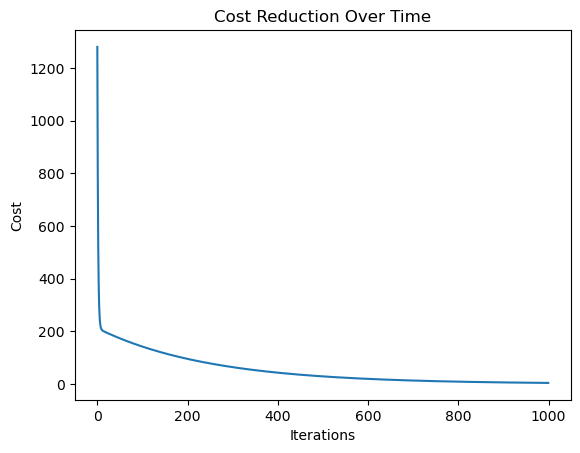

In [8]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction Over Time")
plt.show()

In [9]:
# Predict values
predictions = weight * X + bias

print("Predicted Scores:")
print(predictions)

Predicted Scores:
[46.43993035 51.49892251 56.55791466 61.61690682 66.67589898 71.73489113
 76.79388329 81.85287545]


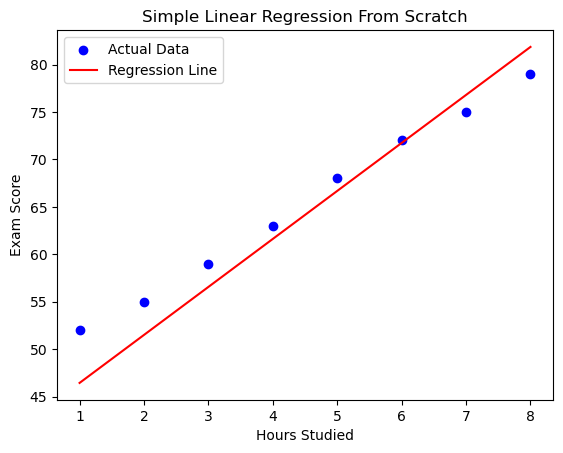

In [10]:
# Original data points
plt.scatter(X, y, color='blue', label='Actual Data')

# Regression line
plt.plot(X, predictions, color='red', label='Regression Line')

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression From Scratch")
plt.legend()
plt.show()

In [11]:
# Example: Predict exam score for 9 hours studied
new_hours = 9
predicted_score = weight * new_hours + bias

print(f"Predicted exam score for {new_hours} hours studied: {predicted_score:.2f}")

Predicted exam score for 9 hours studied: 86.91


In [12]:
def r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

r2 = r2_score(y, predictions)

print("R² Score:", r2)

R² Score: 0.902958885864707


In [13]:
print("Simple Linear Regression Equation:")
print(f"y = {weight:.2f}x + {bias:.2f}")

Simple Linear Regression Equation:
y = 5.06x + 41.38
